Tableau URL : https://public.tableau.com/app/profile/evan.jules/viz/Dashboard_17678031553040/Dashboard1?publish=yes

# I. Introduction

---   
**Project Name:** Video Game Sales Analysis for new Publisher Strategy  
**Created Date:** January 7 2026   
**Author:** Evan Jules   

---
### Project Background
Over the past decade, the gaming industry has grown rapidly and evolved into a highly competitive market driven by changing consumer preferences. 
In this landscape, new publishers must strategically identify the optimal combination of genre, platform, and release timing to maximize their chances of success.

This project aims to analyze historical video game sales data (2010–2019) to identify patterns and trends that can support data-driven decision-making in game publishing strategies.

---

### SMART Objective

**Specific :** Identify the optimal combination of game genre, platform, and release timing for maximizing sales performance.  
**Measurable :** Measured using average global sales and regional sales distribution.   
**Achievable :** Based on historical video game sales dataset.    
**Relevant :** Supports new publishers in designing an effective launch strategy.   
**Time-bound :** Analysis using historical data from 2010–2019.   

---

### Problem Breakdown (5W + 1H)

- Which game genres and platforms generate the highest average sales?
- Which publishers dominate high-performing game genres?
- Which platforms contribute the most to overall game sales?
- When is the optimal release period with relatively lower competition?
- How can new publishers design an optimal launch strategy based on these insights?

---

### Problem Statement

This project focuses on analyzing game genre, platform (console), and trends to identify combinations that yield the highest average sales. 
The goal is to support new publishers in developing data-driven game launch strategies.

---

## II. Import Libraries

---

In [1]:
# Processing Data
import pandas as pd

# for Statistic purpose
from scipy.stats import f_oneway

# Visualize Data
import matplotlib.pyplot as plt

## III. Load Data

---

In [2]:
# Load Data from Excel File
df_games = pd.read_excel('../data/VideoGames_Sales.xlsx')

# sample data (Top 5)
df_games.head(5)

,title,console,genre,publisher,developer,critic_score,total_sales(mil),na_sales(mil),jp_sales(mil),pal_sales(mil),other_sales(mil),release_date
0,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.4,20.32,6.37,0.99,9.85,3.12,2013-09-17
1,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7,19.39,6.06,0.60,9.71,3.02,2014-11-18
2,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.6,16.15,8.41,0.47,5.49,1.78,2002-10-28
3,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,NaN,15.86,9.06,0.06,5.33,1.42,2013-09-17
4,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.1,15.09,6.18,0.41,6.05,2.44,2015-11-06


## IV. Processing Data

---

In [3]:
# Backup Data
df_games_clean = df_games

# New Column Creation
df_games_clean['Year'] = df_games_clean['release_date'].dt.year
df_games_clean['Month'] = df_games_clean['release_date'].dt.month
df_games_clean['Nama_bulan'] = df_games_clean['release_date'].dt.month_name()

# Filtering Data
df_games_clean = df_games_clean[
        (df_games_clean['Year'] >= 2010) & 
        (df_games_clean['Year'] <= 2019)
    ]

# Cleaning Data
df_games_clean = df_games_clean.dropna(subset=['total_sales(mil)'])
df_games_clean = df_games_clean[df_games_clean['total_sales(mil)'] != 0]
df_games_clean = df_games_clean.dropna(subset=(['na_sales(mil)','jp_sales(mil)']), how='all')

# Filling Blank Data
df_games_clean['na_sales(mil)'] = df_games_clean['na_sales(mil)'].fillna(0)
df_games_clean['jp_sales(mil)'] = df_games_clean['jp_sales(mil)'].fillna(0)

# Filtering Platform that will used as reference
Console = ['PC', 'PS2', 'PS3', 'PS4', 'Wii', 'WiiU', 'X360', 'XOne', 'PSP', 'PSV']
df_games_clean = df_games_clean[df_games_clean['console'].str.contains('|'.join(Console))]


## V. Exploratory Data Analysis (EDA) 

---

### Descriptive Statistic

---

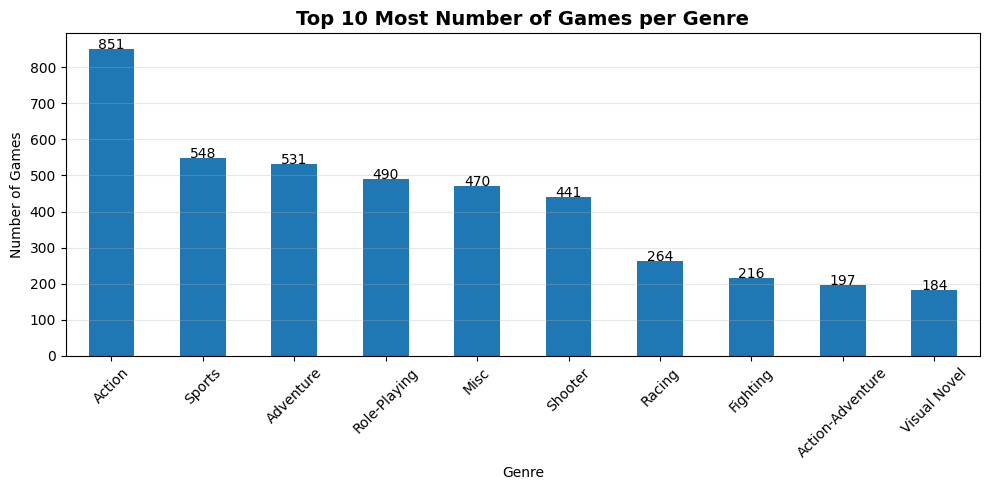

In [4]:
df_genre_count = df_games_clean['genre'].value_counts().head(10)

plt.figure(figsize=(10, 5))

ax = df_genre_count.plot(kind='bar')

plt.title('Top 10 Most Number of Games per Genre', fontsize=14, fontweight='bold')
plt.xlabel('Genre')
plt.ylabel('Number of Games')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

for i, v in enumerate(df_genre_count):
    ax.text(i, v, str(v), ha='center')

plt.tight_layout()
plt.show()

While the graph indicates that the `Action` genre dominates in terms of volume, a `one-way ANOVA` will be conducted to determine whether there are statistically significant differences in mean sales across game genres. This analysis is essential to assess whether the Action genre is the optimal choice for a new publisher.

---

### Inferential Statistic

---

Hypothesis Testing

**H0** : There is no significant difference in mean sales across game genres.   
**H1** : There is a significant difference in mean sales across game genres.

In [5]:
# List of Unique Genre
genres = df_games_clean['genre'].unique()

groups = []

for g in genres:
    data = df_games_clean[df_games_clean['genre'] == g]['total_sales(mil)']
    groups.append(data)

# ANOVA
f_stat, p_value = f_oneway(*groups)

# Result
print("F-statistic:", f_stat)
print("p-value:", p_value)

F-statistic: 20.529442809268033
p-value: 9.529854864381425e-65


The F-statistic indicates the magnitude of differences in mean sales across genres, while the p-value confirms their statistical significance. Although ANOVA shows that significant differences exist, it does not reveal which genre has the highest mean sales. Therefore, the next step is to visualize the average sales for each genre.

---

### Genre Analysis

---

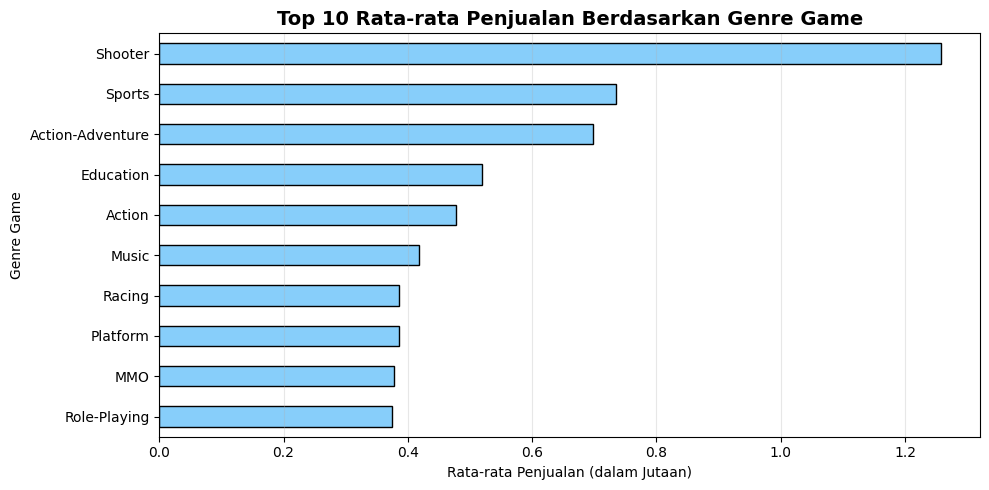

In [6]:
df_barh_raw_genre = (
    df_games_clean
    .groupby('genre')['total_sales(mil)']
    .mean()
    .sort_values(ascending=False)
    .head(10)
    )

df_barh_genre = df_barh_raw_genre.sort_values() 

# Sizing data visualisasi
plt.figure(figsize=(10, 5))

# Menggunakan Horizontal bar untuk membandingkan top 10 genre game dengan rata-rata terbesar
df_barh_genre.plot(kind="barh", color="lightskyblue", edgecolor="black")

# bagian pelengkap
plt.title("Top 10 Rata-rata Penjualan Berdasarkan Genre Game", fontsize=14, fontweight="bold")
plt.xlabel("Rata-rata Penjualan (dalam Jutaan)", fontsize=10)
plt.ylabel("Genre Game", fontsize=10)
plt.grid(axis="x", alpha=0.3) # menampilkan Grid vertikal dengan ketebalan 0.3
plt.tight_layout()
plt.show()

The graph shows that although the `Action` genre dominates in terms of volume, it does not necessarily translate into the highest average sales. Genres such as `Shooter` and `Sports` exhibit higher mean sales. This suggests a competitive and potentially saturated market for Action, where strategic genre selection is more critical than simply following popular trends.

Given the noticeable difference in mean sales between `Shooter` and `Sports`, the `Shooter` will be choosen as the optimal choice for a new publisher due to its superior revenue potential.

As a next step, we will visualize which `publishers` released the most `Shooter` games during the 2010–2019 period.

---

### Dominant Publisher Analysis

---

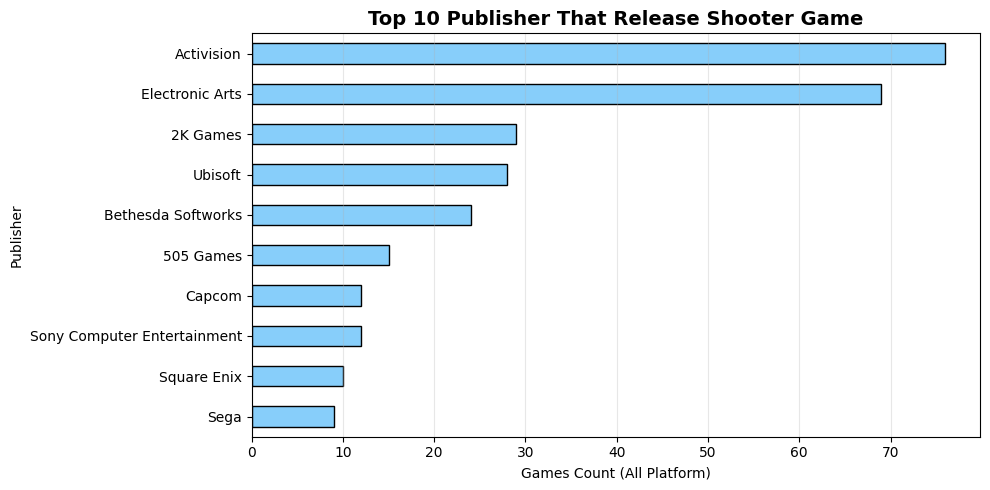

In [7]:
# Filtering data : hanya mengambil data dengan genre "Shooter"
df_games_clean_publisher = df_games_clean[df_games_clean['genre'].str.contains('Shooter')]

# Menghitung banyaknya game yang di buat oleh publisher
df_barh_raw_publisher = (
    df_games_clean_publisher
    .groupby('publisher')['title']
    .count()
    .sort_values(ascending=False)
    .head(10)
)

# mengsortir ulang data agar publisher terbesar berada paling atas pada visualisasi data
df_barh_publisher = df_barh_raw_publisher.sort_values()

# Sizing data visualisasi
plt.figure(figsize=(10, 5))

# Menggunakan Horizontal bar untuk membandingkan top 10 Publisher terbesar yang memproduksi genre game "Shooter"
df_barh_publisher.plot(kind="barh", color="lightskyblue", edgecolor="black")

# bagian pelengkap
plt.title("Top 10 Publisher That Release Shooter Game", fontsize=14, fontweight="bold")
plt.xlabel("Games Count (All Platform)", fontsize=10)
plt.ylabel("Publisher", fontsize=10)
plt.grid(axis="x", alpha=0.3)  # menampilkan Grid vertikal dengan ketebalan 0.3
plt.tight_layout()
plt.show()

Despite the strong revenue potential of the `Shooter` genre, the market is highly concentrated, with major publishers such as `Activision` and `Electronic Arts` dominating in term of release volume. This creates a highly competitive environment for new entrants.

Rather than competing directly, a more effective strategy is to identify release windows with lower activity from dominant publishers, thereby minimizing competitive pressure and increasing the likelihood of market visibility.

---

### Release Timing Analysis

---

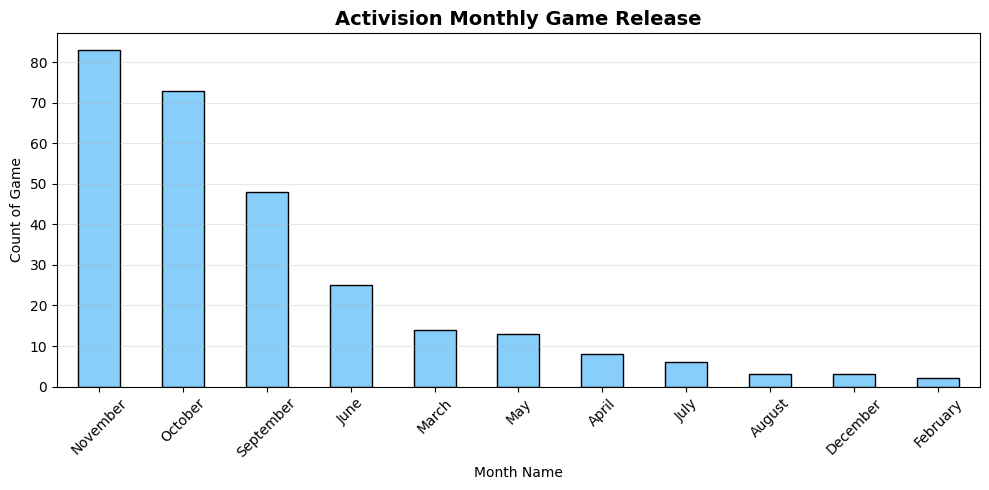

In [8]:
# Filtering data : hanya mengambil game dengan publisher Activision
df_games_clean_Activision = df_games_clean[df_games_clean['publisher'].str.contains('Activision')]

# Menghitung banyaknya game berdasarkan Bulan
df_barh_Activision = (
    df_games_clean_Activision
    .fillna(0)
    .groupby('Nama_bulan')['title']
    .count()
    .sort_values(ascending=False)
)

# Sizing data visualisasi
plt.figure(figsize=(10, 5))

# Menggunakan plot bar untuk melihat banyak game yang di rilis tiap bulannya
df_barh_Activision.plot(kind="bar", color="lightskyblue", edgecolor="black")

# Bagian pelengkap
plt.title("Activision Monthly Game Release", fontsize=14, fontweight="bold")
plt.xlabel("Month Name", fontsize=10)
plt.ylabel("Count of Game", fontsize=10)
plt.xticks(rotation=45) # memiringkan label X 45 derajat
plt.grid(axis="y", alpha=0.3)  # menampilkan Grid vertikal dengan ketebalan 0.3
plt.tight_layout()
plt.show()

The release pattern of `Activision` reveals a strong concentration in `October` and `November`, likely aligned with the holiday sales cycle. This creates periods of intense competition, making these months less favorable for new entrants. Conversely, months with lower release activity, such as `February` and `August`, present strategic opportunities to launch new titles with reduced competitive pressure and potentially higher market visibility.

Based on this pattern, `February` is identified as the optimal release window for a new `Shooter` game, as it offers lower competitive intensity and a greater opportunity to capture market attention


---

### Platform Analysis

---

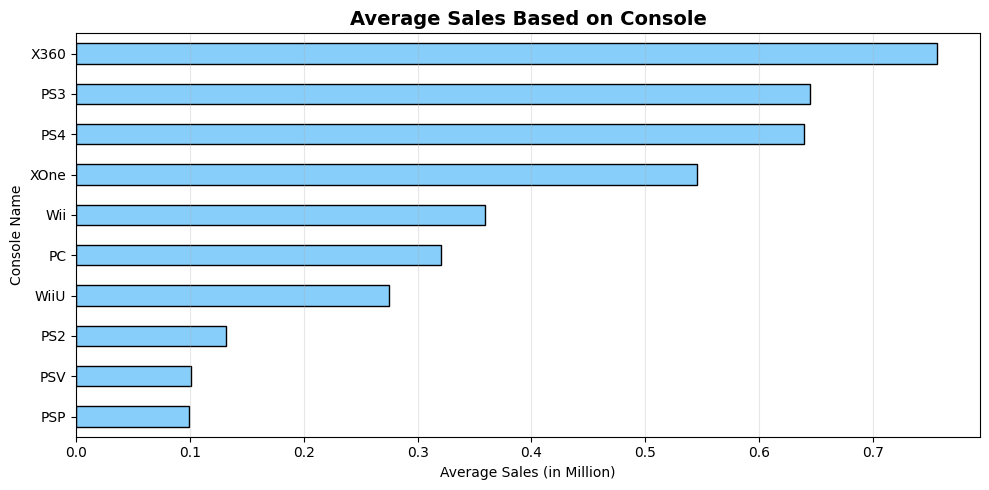

In [9]:
# Menghitung Rata-rata total penjualan berdasarkan konsol
df_barh_raw_console = (
    df_games_clean
    .groupby('console')['total_sales(mil)']
    .mean()
    .sort_values(ascending=False)
)

# mengsortir ulang data agar konsol dengan Rata-rata penjualan terbesar berada di paling atas
df_barh_console = df_barh_raw_console.sort_values()

# Sizing data visualisasi
plt.figure(figsize=(10, 5))

# Menggunakan Horizontal bar untuk membandingkan Rata-rata penjualan tiap konsol
df_barh_console .plot(kind="barh", color="lightskyblue", edgecolor="black")

# bagian pelengkap
plt.title("Average Sales Based on Console", fontsize=14, fontweight="bold")
plt.xlabel("Average Sales (in Million)", fontsize=10)
plt.ylabel("Console Name", fontsize=10)
plt.grid(axis="x", alpha=0.3)  # menampilkan Grid vertikal dengan ketebalan 0.3
plt.tight_layout()
plt.show()


The graph indicates that Xbox 360 has the highest average sales among all platforms, followed by PlayStation 3 and PlayStation 4.

This suggests that home consoles, particularly Xbox 360 and the PlayStation series, deliver higher average sales compared to other platforms, making them more attractive options for maximizing revenue. In contrast, handheld and older-generation platforms exhibit significantly lower performance, indicating more limited market potential.

Based on this analysis, Xbox 360 emerges as the most favorable platform for releasing a new Shooter game.

---

==================================================================================================================================
## VI. CONCLUSION

As a new Publisher in video game, sales performance is influenced by a combination of genre selection, platform choice, and release timing rather than sheer production volume.

While the Action genre dominates in terms of the number of releases, it does not translate into the highest average sales, indicating a saturated and highly competitive market. In contrast, the Shooter genre shows the strongest revenue potential, making it a more optimal choice for new publishers.

From a platform perspective, Xbox 360 emerges as the most favorable platform due to its consistently higher average sales compared to others. Additionally, release timing plays a critical role, as major publishers concentrate their launches in peak periods such as October and November, creating intense competition.

Therefore, launching in lower-competition periods, particularly February, provides a strategic advantage for new entrants to gain visibility and maximize performance.

Overall, a data-driven launch strategy that combines high-performing genre (Shooter), strong platform (Xbox 360), and optimal timing (February) significantly increases the likelihood of commercial success for new publishers.

==================================================================================================================================